In [1]:
import sys
print(sys.path)

sys.path.insert(1, '/home/andreas/prj_AH/analysis_buckle') ## this is the path to the pybuckle package.
                                                            ## only necessary if the location is not in your
                                                            ## python path


import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt

import h5py
        
import astropy.units as units           # astropy is only used for conveniently convert units, 
from astropy.constants import k_B, N_A  # not strictly necessary
import MDAnalysis as mda

from scipy.integrate import cumtrapz

from pybuckle.fourier import *
from pybuckle.solveBVP import BuckleBVPSolver, makeTables
from pybuckle.getshapecoeff import BucklesShapeFCoeff
from pybuckle.fitshape import FitShape, prefit_fun
from pybuckle.misc import calc_curvature, calc_dKds, min_image_dist, rotateVec

SMALL_SIZE = 16
MEDIUM_SIZE = 20 
BIGGER_SIZE = 24

plt.rc('axes', labelsize=MEDIUM_SIZE)
plt.rc('axes', titlesize=SMALL_SIZE)
plt.rc('xtick', labelsize=SMALL_SIZE)
plt.rc('ytick', labelsize=SMALL_SIZE)

['/home/andreas/prj_AH/buckle_ashuffle_x_pw_rep1', '/usr/lib/python38.zip', '/usr/lib/python3.8', '/usr/lib/python3.8/lib-dynload', '', '/home/andreas/.local/lib/python3.8/site-packages', '/usr/local/lib/python3.8/dist-packages', '/usr/local/lib/python3.8/dist-packages/memsurfer-1.1.0-py3.8-linux-x86_64.egg', '/usr/local/lib/python3.8/dist-packages/vtk-9.2.0rc2-py3.8-linux-x86_64.egg', '/usr/local/lib/python3.8/dist-packages/numpy-1.23.2-py3.8-linux-x86_64.egg', '/usr/local/lib/python3.8/dist-packages/wslink-1.7.0-py3.8.egg', '/usr/local/lib/python3.8/dist-packages/matplotlib-3.5.3-py3.8-linux-x86_64.egg', '/usr/local/lib/python3.8/dist-packages/aiohttp-3.8.1-py3.8-linux-x86_64.egg', '/usr/local/lib/python3.8/dist-packages/kiwisolver-1.4.4-py3.8-linux-x86_64.egg', '/usr/local/lib/python3.8/dist-packages/fonttools-4.35.0-py3.8.egg', '/usr/local/lib/python3.8/dist-packages/cycler-0.11.0-py3.8.egg', '/usr/local/lib/python3.8/dist-packages/yarl-1.8.1-py3.8-linux-x86_64.egg', '/usr/local/li

In [2]:
plt.rcParams['figure.figsize'] = 14, 14 #/ aspect_ratio
plt.rcParams['legend.fontsize'] = SMALL_SIZE

In [3]:
%load_ext autoreload
#%load_ext line_profiler

%autoreload 2

In [4]:
basedir = '/home/andreas/prj_AH/NAME/repREP/'
workdir = basedir
umbdir = workdir + 'UMBRELLA/'

frame_info = pd.read_csv(umbdir + 'caught-output.dat', header=0, delim_whitespace=True) 

#membraneOnly_box_x = np.loadtxt(basedir + 'membraneOnly/NPT/box-x.xvg', skiprows=24)

u = mda.Universe(workdir + 'pull.tpr', workdir + 'pull_reduced.xtc')

lx = u.dimensions[0] / 10
ly = u.dimensions[1] / 10
lz = u.dimensions[2] / 10
print(lx, ly, lz)

#L0 = np.mean(membraneOnly_box_x[:,1])
L0 = 30
print('L0 = %f' %L0)
Lx = lx
g = Lx / L0
print(g)


21.0 10.0 22.20881042480469
L0 = 30.000000
0.7


Conversion of the force constant from gromacs units to kT

In [5]:
k_gromacs = 100
T = 310
k_gromacs_units = k_gromacs * units.kJ / units.mol / units.nm**2 
k_kbT = k_gromacs_units / (k_B * T * units.K * N_A).to('kJ/mol')

k = k_kbT.value
k

38.79753388475033

Load shape data

In [6]:
hf = h5py.File(umbdir + 'shape_data.h5', 'r') 

In [7]:
list(hf.keys())

['minim_g_out_all', 'shape_coeff']

In [8]:
x0_mean = np.mean(hf['minim_g_out_all'][:,0])
x0_std  = np.std(hf['minim_g_out_all'][:,0]) 

z0_mean = np.mean(hf['minim_g_out_all'][:,1])
z0_std  = np.std(hf['minim_g_out_all'][:,1])

g_mean = np.mean(hf['minim_g_out_all'][:,2])
g_std  = np.std(hf['minim_g_out_all'][:,2])

print(x0_mean, x0_std, x0_std / x0_mean)
print(z0_mean, z0_std, z0_std / z0_mean)
print(g_mean,  g_std,  g_std  / g_mean)

6.391633757734024 0.03805713370444355 0.005954210636426649
6.755329256312972 0.03540099560721064 0.0052404545010338015
0.7197899090307225 0.0025862957509332745 0.0035931258808782284


In [9]:
L_hat = lx / g_mean 
L_hat

29.175179780276228

In [10]:
s_plot = hf['shape_coeff/s_plot'][:].reshape(-1) 
print(s_plot)

[-0.323975 -0.323875 -0.323775 ...  0.675825  0.675925  0.676025]


In [11]:
s01 = np.linspace(0, 1, int(1e6)+1)
outsideshaper = BucklesShapeFCoeff()
fitted_shape_coeff = outsideshaper.get_FCoeff(g_mean, Lx, s=s01)

ax_at_fitted_g = fitted_shape_coeff[12] 
az_at_fitted_g = fitted_shape_coeff[13]
X = fitted_shape_coeff[0]
Z = fitted_shape_coeff[1]

curv = calc_curvature(fitted_shape_coeff)
dKds = calc_dKds(fitted_shape_coeff)

dXds = fitted_shape_coeff[4]
dZds = fitted_shape_coeff[5]


In [12]:
absdrds = np.sqrt((dXds / L_hat)**2 + (dZds / L_hat)**2) 
absdrds 

array([1.00000019, 1.00000019, 1.00000019, ..., 1.00000019, 1.00000019,
       1.00000019])

Calculate offset curve. In this case the offset used was 2 nm. 

In [13]:
d = 2.0

s_middle = np.zeros_like(s01) 
s_offset = np.zeros_like(s01)

s_middle[1:] = cumtrapz(absdrds, dx=(s01[1:] - s01[:-1]))
s_offset[1:] = cumtrapz(np.abs(1 + curv * d), dx=(s01[1:] - s01[:-1]))

L_middle = L_hat * s01
L_offset = L_hat * s_offset

In [14]:
nWin = frame_info.shape[0] 
print(nWin)
s_window = np.linspace(0.0, 0.5, nWin) # enter the used s range here
s_win_flip = np.flip(s_window)
s_window, s_win_flip

64


(array([0.        , 0.00793651, 0.01587302, 0.02380952, 0.03174603,
        0.03968254, 0.04761905, 0.05555556, 0.06349206, 0.07142857,
        0.07936508, 0.08730159, 0.0952381 , 0.1031746 , 0.11111111,
        0.11904762, 0.12698413, 0.13492063, 0.14285714, 0.15079365,
        0.15873016, 0.16666667, 0.17460317, 0.18253968, 0.19047619,
        0.1984127 , 0.20634921, 0.21428571, 0.22222222, 0.23015873,
        0.23809524, 0.24603175, 0.25396825, 0.26190476, 0.26984127,
        0.27777778, 0.28571429, 0.29365079, 0.3015873 , 0.30952381,
        0.31746032, 0.32539683, 0.33333333, 0.34126984, 0.34920635,
        0.35714286, 0.36507937, 0.37301587, 0.38095238, 0.38888889,
        0.3968254 , 0.4047619 , 0.41269841, 0.42063492, 0.42857143,
        0.43650794, 0.44444444, 0.45238095, 0.46031746, 0.46825397,
        0.47619048, 0.48412698, 0.49206349, 0.5       ]),
 array([0.5       , 0.49206349, 0.48412698, 0.47619048, 0.46825397,
        0.46031746, 0.45238095, 0.44444444, 0.43650794, 0.

In [15]:
sWin_ndx = np.argmin(np.abs(s_win_flip.reshape(-1,1) -  s01), axis=1)
sWin_ndx 

array([500000, 492063, 484127, 476190, 468254, 460317, 452381, 444444,
       436508, 428571, 420635, 412698, 404762, 396825, 388889, 380952,
       373016, 365079, 357143, 349206, 341270, 333333, 325397, 317460,
       309524, 301587, 293651, 285714, 277778, 269841, 261905, 253968,
       246032, 238095, 230159, 222222, 214286, 206349, 198413, 190476,
       182540, 174603, 166667, 158730, 150794, 142857, 134921, 126984,
       119048, 111111, 103175,  95238,  87302,  79365,  71429,  63492,
        55556,  47619,  39683,  31746,  23810,  15873,   7937,      0])

In [16]:
xi_ref_middle = L_middle[sWin_ndx] 
xi_ref_middle

array([14.58758989, 14.35602649, 14.12449226, 13.89292886, 13.66139463,
       13.42983123, 13.198297  , 12.9667336 , 12.73519938, 12.50363597,
       12.27210175, 12.04053834, 11.80900412, 11.57744072, 11.34590649,
       11.11434309, 10.88280886, 10.65124546, 10.41971123, 10.18814783,
        9.9566136 ,  9.7250502 ,  9.49351597,  9.26195257,  9.03041835,
        8.79885494,  8.56732072,  8.33575732,  8.10422309,  7.87265969,
        7.64112546,  7.40956206,  7.17802783,  6.94646443,  6.7149302 ,
        6.4833668 ,  6.25183257,  6.02026917,  5.78873495,  5.55717154,
        5.32563732,  5.09407392,  4.86253969,  4.63097629,  4.39944206,
        4.16787866,  3.93634443,  3.70478103,  3.4732468 ,  3.2416834 ,
        3.01014917,  2.77858577,  2.54705155,  2.31548814,  2.08395392,
        1.85239051,  1.62085629,  1.38929289,  1.15775866,  0.92619526,
        0.69466103,  0.46309763,  0.2315634 ,  0.        ])

In [17]:
xi_ref_offset = L_offset[sWin_ndx] 
xi_ref_offset

array([14.58758989, 14.24420695, 13.90119125, 13.55877843, 13.21737295,
       12.87720135, 12.53865445, 12.20194308, 11.86743777, 11.53532831,
       11.2059597 , 10.87949676, 10.55625535, 10.23637307,  9.92013466,
        9.60764969,  9.29917132,  8.99478168,  8.69470311,  8.39899198,
        8.10784158,  7.82128482,  7.53948828,  7.26246412,  6.99035471,
        6.72315416,  6.46098313,  6.20382016,  5.95176641,  5.70478692,
        5.46296501,  5.22625366,  4.99471943,  4.76830398,  4.54705743,
        4.33091013,  4.11989542,  3.91393158,  3.71303416,  3.51710791,
        3.32614886,  3.14004622,  2.9587743 ,  2.78220426,  2.61028621,
        2.44287054,  2.27988065,  2.12114349,  1.96655341,  1.81591157,
        1.66908153,  1.52583701,  1.38600996,  1.2493461 ,  1.11564626,
        0.98462891,  0.85606576,  0.72965033,  0.60512878,  0.48217358,
        0.3605106 ,  0.23979661,  0.11974386,  0.        ])

Read in pull data directly from gromacs output files. The number of rows to skip might need to be adapted to your output.

In [41]:
pullx0 = pd.read_csv(umbdir + 'umbrella%d_pullx.xvg' %frame_info['frame'].iloc[56],
                        names=['t', 'dxi'], 
                        skiprows=17,
                        usecols=[0,1],
                        delim_whitespace=True).to_numpy()

pullx = np.zeros((pullx0.shape[0], nWin+1))

pullx[:,0:2] = pullx0
nDataPoints = np.zeros(pullx.shape[1] - 1)
nDataPoints[0] = pullx0.shape[0]

for i, frame in enumerate(frame_info['frame'].iloc[1:]):
    print(i+2, frame)
    temp_data = (pd.read_csv(umbdir + 'umbrella%d_pullx.xvg' %frame, 
                                usecols=[1], 
                                names=['dxi'], 
                                skiprows=25, 
                                delim_whitespace=True).to_numpy()).reshape(-1)
    print(temp_data.shape)
    nDataPoints[i+1] = temp_data.shape[0]
    pullx[:int(nDataPoints[i+1]), i+2] = temp_data
    


2 21
(199993,)
3 30
(199993,)
4 43
(199993,)
5 52
(199993,)
6 62
(199993,)
7 70
(199993,)
8 73
(199993,)
9 91
(199993,)
10 103
(199993,)
11 116
(199993,)
12 118
(199993,)
13 130
(199993,)
14 136
(199993,)
15 146
(199993,)
16 159
(199993,)
17 162
(199993,)
18 168
(199993,)
19 172
(199993,)
20 185
(199993,)
21 195
(199993,)
22 197
(199993,)
23 203
(199993,)
24 204
(199993,)
25 214
(199993,)
26 221
(199993,)
27 228
(199993,)
28 231
(199993,)
29 234
(265764,)
30 235
(265515,)
31 243
(265511,)
32 244
(265757,)
33 251
(199993,)
34 253
(199993,)
35 260
(199993,)
36 261
(199993,)
37 263
(199993,)
38 264
(199993,)
39 266
(199993,)
40 271
(199993,)
41 274
(199993,)
42 275
(199993,)
43 276
(199993,)
44 279
(199993,)
45 289
(199993,)
46 290
(199993,)
47 293
(199993,)
48 297
(199993,)
49 298
(199993,)
50 303
(199993,)
51 304
(199993,)
52 314
(199993,)
53 316
(199993,)
54 327
(199993,)
55 329
(199993,)
56 332
(199993,)
57 333
(317430,)
58 336
(304173,)
59 339
(304208,)
60 342
(317438,)
61 348
(14129

In [42]:
nBins = 2000 

xi_bins = np.linspace(xi_ref_offset[-1], L_hat / 2, nBins+1)
xi_bins

array([0.00000000e+00, 7.29379495e-03, 1.45875899e-02, ...,
       1.45730023e+01, 1.45802961e+01, 1.45875899e+01])

In [43]:
xi_bins_center = xi_bins[:-1] + (xi_bins[1] - xi_bins[0]) / 2 
xi_bins_center

array([3.64689747e-03, 1.09406924e-02, 1.82344874e-02, ...,
       1.45693554e+01, 1.45766492e+01, 1.45839430e+01])

In [44]:
xi = pullx[1000:10000].copy() # skip first 100 ns of 1000 ns (every step in pullx file is 100 ps) 
xi[:,1:] += xi_ref_offset.reshape(1, nWin)
print(pullx.shape)
print(xi.shape)


(317438, 65)
(307438, 65)


In this tutorial, I simply calculate the mean and the variance. Normally, you want to decorrelate the data and do some statistical tests, as described in the paper in section 2.2. This is also necessary for estimating the statistical error.

In [45]:
xi_mean = np.zeros(nDataPoints.shape[0]) 
xi_var = np.zeros(nDataPoints.shape[0])

for i in range(nDataPoints.shape[0]):
    xi_mean[i] = np.mean(xi[:int(nDataPoints[i]),i+1], axis=0) 
    xi_var[i] = np.var(xi[:int(nDataPoints[i]),i+1], axis=0, ddof=1)
    if xi_var[i] == 0.0:
        xi_var = 1e-10

In [47]:
xi[0] 

array([1.00000000e+04, 1.47265079e+01, 1.42719571e+01, 1.37519172e+01,
       1.33827764e+01, 1.30716640e+01, 1.31390884e+01, 1.26839454e+01,
       1.22810568e+01, 1.17529858e+01, 1.20076823e+01, 1.11689435e+01,
       1.08962109e+01, 1.04246804e+01, 1.01371525e+01, 9.94060556e+00,
       9.40660669e+00, 9.11157632e+00, 9.00644108e+00, 8.57334711e+00,
       8.49342538e+00, 7.81586858e+00, 7.62178282e+00, 7.54927738e+00,
       7.19930812e+00, 7.24320671e+00, 6.89416316e+00, 6.52197413e+00,
       6.34575316e+00, 5.76894241e+00, 5.47914892e+00, 5.56052971e+00,
       5.43766466e+00, 5.21610343e+00, 4.51590798e+00, 4.52840023e+00,
       4.44303913e+00, 4.08026412e+00, 4.03773558e+00, 3.99576416e+00,
       3.37830991e+00, 3.16439286e+00, 3.10056552e+00, 3.00967800e+00,
       2.69161316e+00, 2.46842921e+00, 2.35033014e+00, 2.05597665e+00,
       1.99268249e+00, 2.05268141e+00, 1.67919257e+00, 1.77263453e+00,
       1.19187401e+00, 1.46874786e+00, 1.21559830e+00, 1.05326966e+00,
      

In [48]:
dAi_udx =( (xi_bins_center.reshape(-1,1) - xi_mean.reshape(1,-1))  
            / xi_var - k * (xi_bins_center.reshape(-1,1) - xi_ref_offset.reshape(1,-1)) )
dAi_udx 

array([[ 4.93290851e+01, -1.06792609e+02, -6.96510259e+01, ...,
        -4.53415093e+00, -8.73653788e-02,  6.11982820e-01],
       [ 4.93031986e+01, -1.06738395e+02, -6.96147927e+01, ...,
        -4.39892513e+00, -1.45389744e-02,  6.09225355e-01],
       [ 4.92773122e+01, -1.06684181e+02, -6.95785594e+01, ...,
        -4.26369933e+00,  5.82874300e-02,  6.06467889e-01],
       ...,
       [-2.36615263e+00,  1.47251314e+00,  2.70685831e+00, ...,
         2.65511774e+02,  1.45346964e+02, -4.89467608e+00],
       [-2.39203908e+00,  1.52672702e+00,  2.74309160e+00, ...,
         2.65647000e+02,  1.45419791e+02, -4.89743355e+00],
       [-2.41792553e+00,  1.58094090e+00,  2.77932490e+00, ...,
         2.65782225e+02,  1.45492617e+02, -4.90019101e+00]])

In [49]:
Pi_b = 1 / np.sqrt(xi_var * 2 * np.pi) * np.exp(-0.5 * (xi_bins_center.reshape(-1,1) - xi_mean.reshape(1,-1))**2 / xi_var)  
print(Pi_b.shape) 
print(xi_var)

(2000, 64)
[0.02837006 0.02163078 0.02284919 0.02317395 0.0278488  0.0231207
 0.02388056 0.02281434 0.0250502  0.02207325 0.02138437 0.02042117
 0.02278164 0.0235699  0.02624849 0.0236363  0.0241833  0.02161436
 0.02662117 0.02298765 0.02838331 0.02634765 0.02282851 0.02290767
 0.02850235 0.02604641 0.02204239 0.02234785 0.02508786 0.02389212
 0.0232063  0.02349249 0.02311936 0.02270418 0.02525016 0.02464632
 0.03120084 0.02063227 0.02385304 0.03090099 0.0248949  0.02820037
 0.0247594  0.02681791 0.02162469 0.02806962 0.02147213 0.0236543
 0.03013713 0.01997344 0.02027104 0.02386227 0.02219914 0.02073852
 0.02633326 0.02595996 0.02837007 0.02387055 0.0227308  0.02831426
 0.0308513  0.01744063 0.02049926 0.02602846]


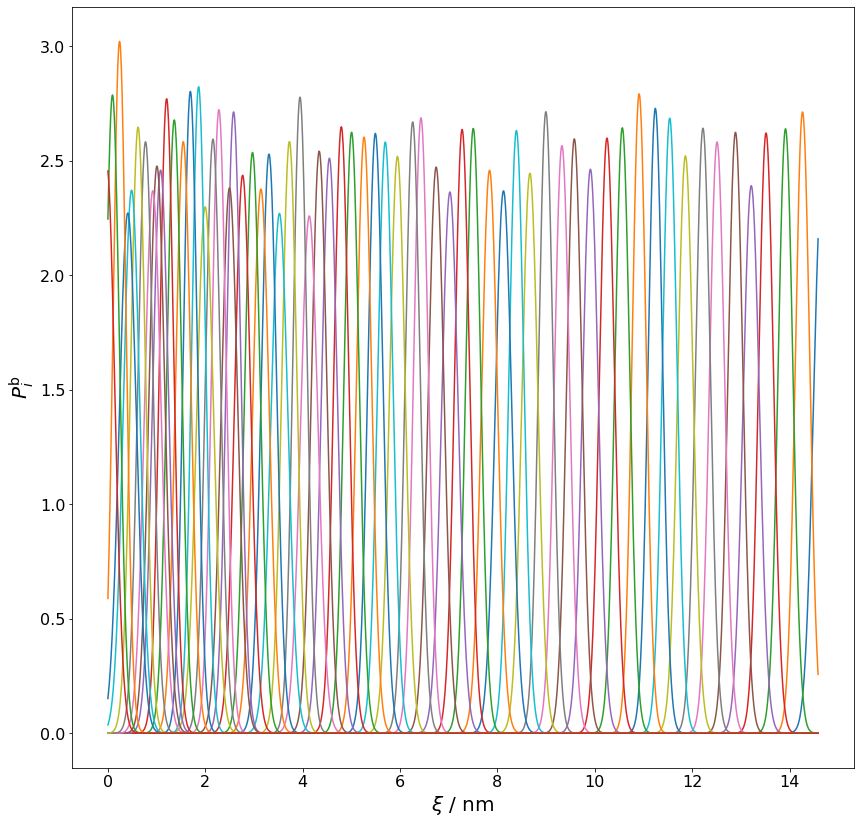

In [50]:
plt.plot(xi_bins_center, Pi_b[:,0::1]) 

plt.xlabel(r'$\xi$ / nm')
plt.ylabel('$P_{i}^{\mathrm{b}}$')
plt.show()

In [51]:
pi_nDataPoints = nDataPoints * Pi_b / np.sum(nDataPoints * Pi_b, axis=1).reshape(-1,1) 

product=nDataPoints * Pi_b
print(product.shape)
print(Pi_b[0])

(2000, 64)
[0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
 4.12511013e-306 4.72753275e-295 1.97294658e-282 5.38927258e-256
 2.23494879e-235 6.40360648e-220 3.84299950e-178 4.26464332e-166
 2.44034861e-119 5.69205226e-164 1.03201094e-126 1.64902765e-087
 1.04842854e-095 2.43408459e-076 1.29707482e-077 2.71712176e-062
 3.74518118e-067 1.43595777e-048 8.46719359e-053 5.10434508e-043
 4.27834021e-029 5.64614624e-038 5.62812230e-031 4.21797783e-022
 1.85188076e-018 1.69582754e-015 5.43813229e-010 8.25117758e-009
 7.52685615e-007 9.72414684e-006 5.76337364e-004 3.62916072e-002
 1.51275920e-0

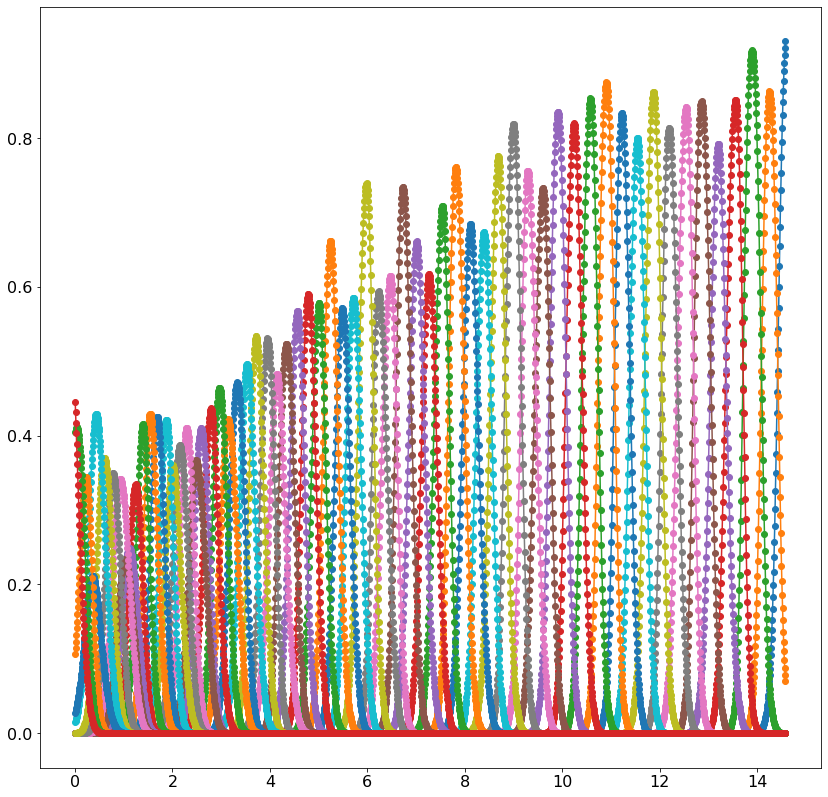

In [52]:
plt.plot(xi_bins_center, pi_nDataPoints[:,0::1], 'o-') 
plt.show()

In [53]:
dA_udx = np.sum(pi_nDataPoints * dAi_udx, axis=1 ) 


In [54]:
pmf_xi = np.cumsum(dA_udx * (xi_bins[1] - xi_bins[0])  )  

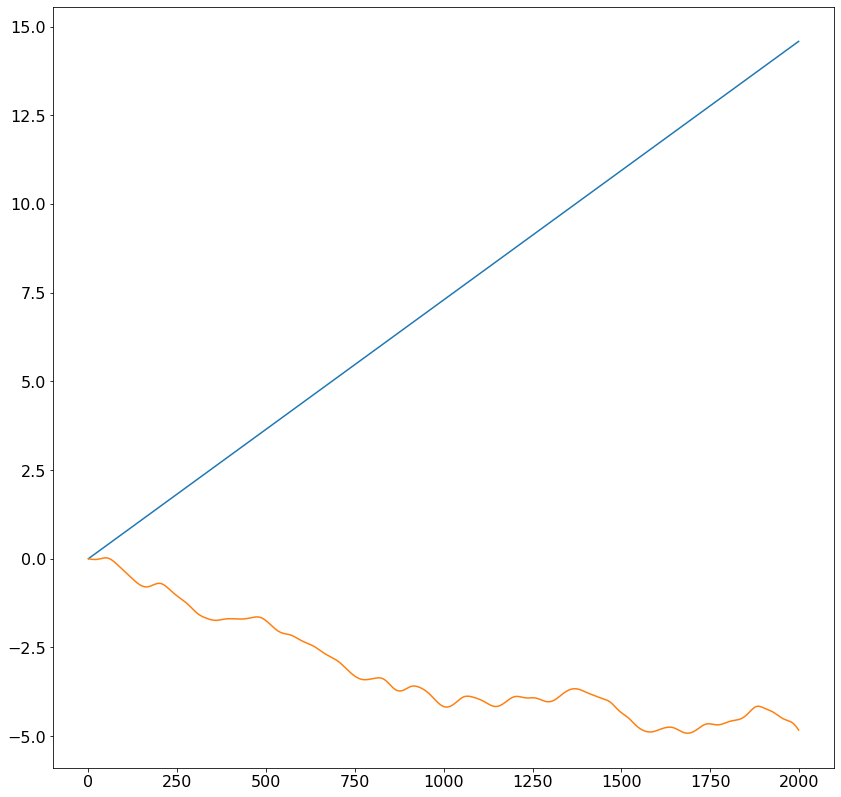

In [55]:
plt.plot(xi_bins_center  )
plt.plot(pmf_xi)

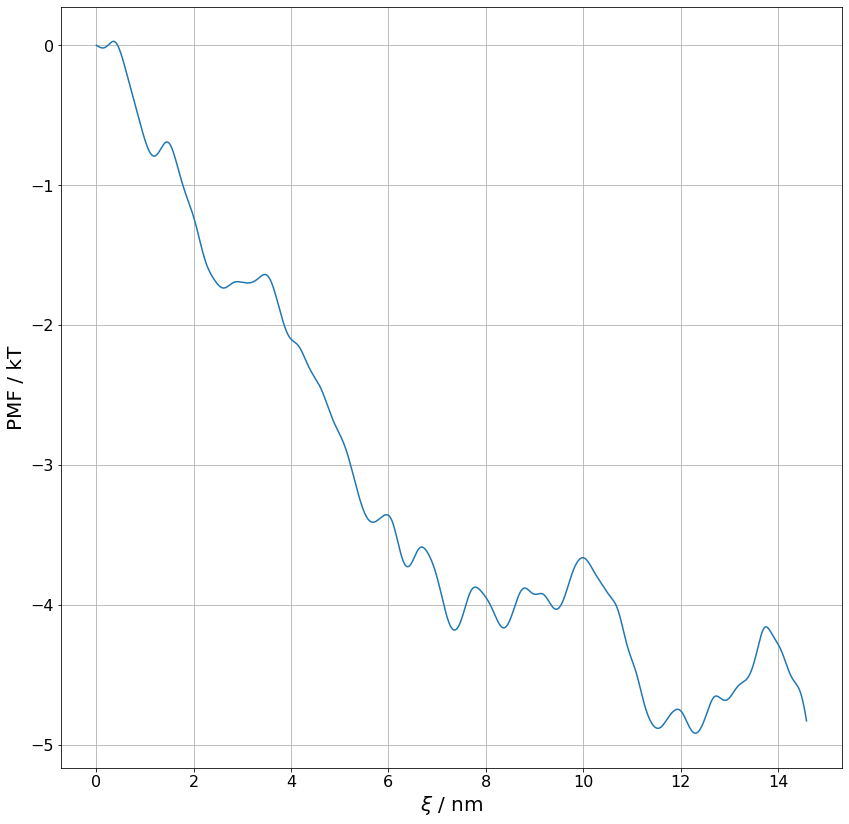

In [56]:
plt.plot(xi_bins_center, pmf_xi, color='C0') 

plt.xlabel(r'$\xi$ / nm')
plt.ylabel('PMF / kT')
plt.grid()

plt.show()

In [57]:
#s_edges = np.linspace(0.25,0.5, 2001)
s_edges = np.linspace(0.0,0.5, 2001) 
s_center_bins = s_edges[:-1] + (s_edges[1] - s_edges[0]) / 2
s_center_bins

array([1.25000e-04, 3.75000e-04, 6.25000e-04, ..., 4.99375e-01,
       4.99625e-01, 4.99875e-01])

In [58]:
fitted_shape_coeff_bins = outsideshaper.get_FCoeff(g_mean, Lx, s=s_center_bins)

curv_bins = calc_curvature(fitted_shape_coeff_bins) 
dKds_bins = calc_dKds(fitted_shape_coeff_bins)

In [59]:
pmf_s = pmf_xi + np.log(np.abs(1 / (np.abs(1 + curv_bins * d) * L_hat))) 
pmf_K = pmf_xi + np.log(np.abs(1 / (np.abs(1 + curv_bins * d) * L_hat) * dKds_bins))

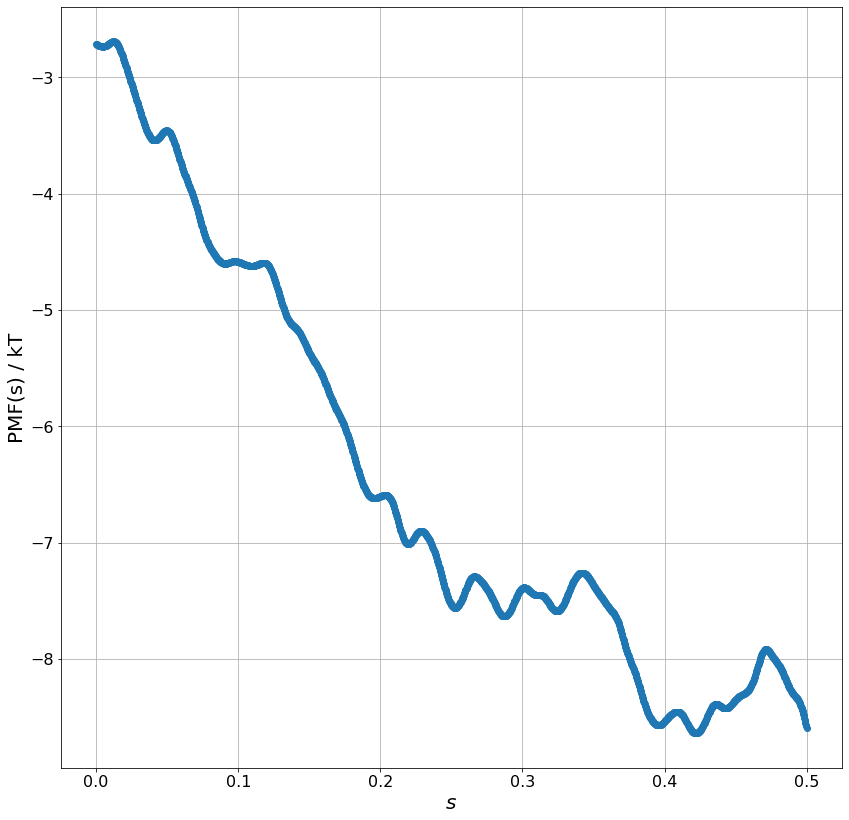

In [60]:
plt.plot(s_center_bins, pmf_s, 'o') 

plt.grid()

plt.xlabel(r'$s$')
plt.ylabel(r'PMF(s) / kT')

plt.show()

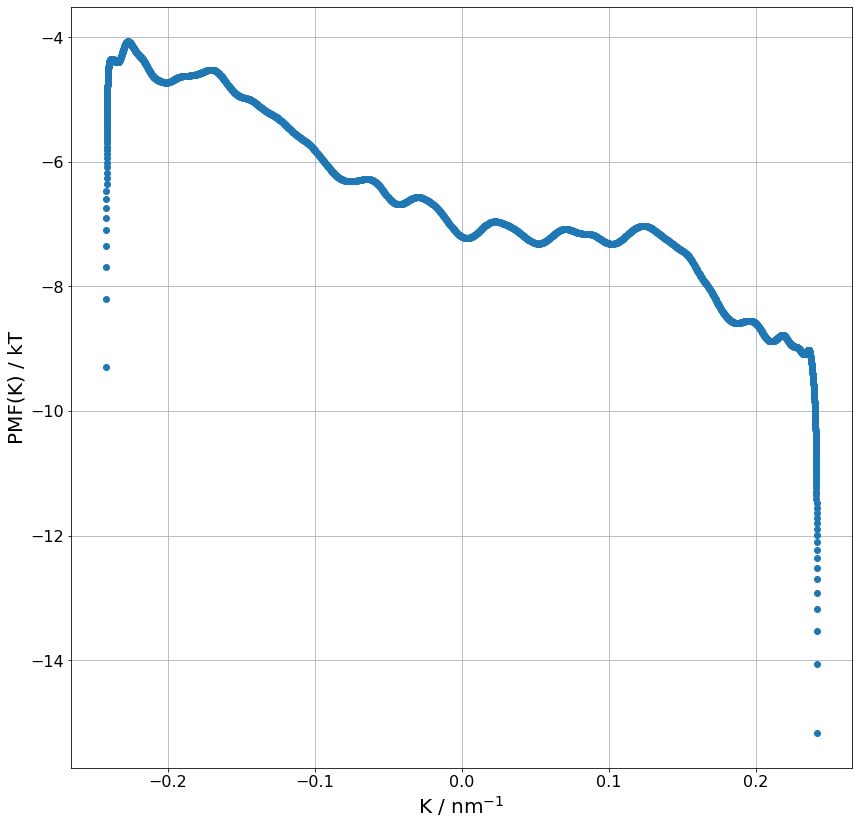

In [61]:
plt.plot(curv_bins, pmf_K, 'o')
 
plt.grid()

plt.xlabel(r'K / nm$^{-1}$')
plt.ylabel(r'PMF(K) / kT')

plt.show()

In [62]:
def smooth(x,n):

    # ensure n is odd
    if (n % 2) == 0:
        n += 1

    # calculate wing size 
    wing_size = int((n-1)/2)

    # initiate x_smooth (no need to change first and last value)
    x_smooth = x.copy() # brackets ensures list x is not edited
    j = 1
    rest = len(x)-j
    while j < len(x)-1:
        if (j < wing_size) or (rest-1 < wing_size) > j:
            i_max = j
        elif rest-1 < wing_size:
            i_max = rest-1
        else:
            i_max = wing_size
        sum = x[j]
        for i in range(1,i_max+1):
            sum += x[j-i] + x[j+i]
        x_smooth[j] = sum/(2*i_max+1)
        j += 1
        rest = len(x) - j

    return x_smooth

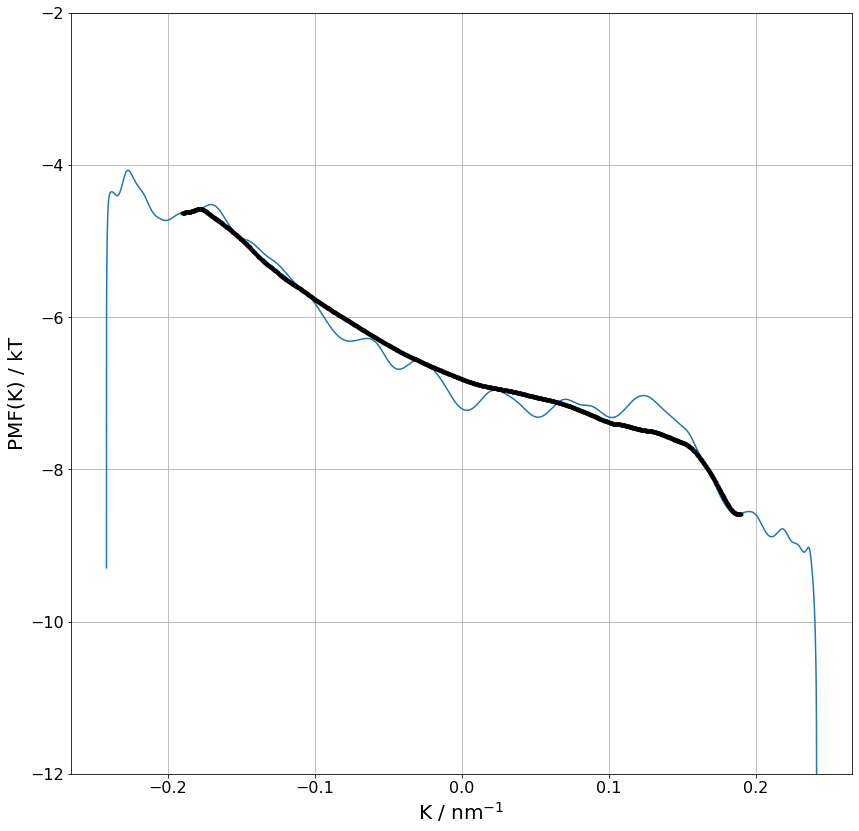

In [63]:
from scipy.optimize import curve_fit
xmin,xmax = -0.19,0.19
idx = np.where((curv_bins<xmax) & (curv_bins > xmin))
#print(idx)
n=600
xnew = curv_bins[idx]
ynew = pmf_K[idx]
yav = smooth(pmf_K[idx],n)

with open('pmf_100_1000.dat','w') as f:
    for (xi,yi,yavi) in zip(xnew,ynew,yav):
        f.write('%f %f %f\n' % (xi,yi,yavi))
                
def func(x,a,b,c):
    y = a*(x-b)**2+c
    return y

#popt,pcov = curve_fit(func,xnew,ynew,p0=[1,0.2,-10])
#fit = func(xnew,*popt)

plt.plot(curv_bins,pmf_K)
plt.plot(xnew, yav, '.',color='black')
#plt.plot(xnew,fit,color='red')

plt.grid()

plt.xlabel(r'K / nm$^{-1}$')
plt.ylabel(r'PMF(K) / kT')
#plt.xlim(-0.2,0.2)
plt.ylim(-12,-2)
plt.show()